<img src="https://s3-us-west-2.amazonaws.com/public.notion-static.com/7fa59d58-ba42-4de1-840a-e2e31ab9ce3b/ba416d9e-ee4d-4b7a-a9fe-a506333af2b7.png" alt="Abstract Banner" width="100%" height="200" style="object-fit: cover; border-radius: 8px;">

by: Elmar Leonard, Muhammad Rafi Andrianto and Valencia


# **Section 0: Project Initialization**

## **0.1 Importing Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
DATA_DIR = 'Data' 

df = pd.read_csv(f'merged_v2.csv')
pd.set_option('display.max_columns', None)
df.shape

(113425, 47)

# **Section 1: Business Explanation**

This section frames the project before any modeling begins: who Olist is, what problem we are solving, for who, how we will approach it, and how we will know it worked. Every claim below is grounded in the preliminary EDA already performed on this dataset not assumptions.


## **1.1 Business Context**

Olist is the largest department store in Brazilian online marketplaces. It does not sell its own products, instead, it operates a multi seller marketplace platform that connects small to medium sized Brazilian businesses to major sales platforms without those sellers needing to build their own e-commerce structure.

Because Olist itself doesn't control manufacturing or (in most cases) directly control the carrier's performance, its reputation depends entirely on the combined performance of thousands of independent sellers (3,095 in this dataset) and its logistics network, spread across all 27 Brazilian states. A bad experience with any one seller or shipping route reflects on the Olist platform as a whole, since customers experience Olist as one marketplace, not as individual sellers.

This is why **customer satisfaction** functions as Olist's core success metric. Low satisfaction reflected in low review scores can damage a seller's reputation and sales performance, which in turn threatens the health of Olist's whole multi-seller ecosystem. High satisfaction, conversely, drives customer retention and repeat purchases, supporting the platform's long-term sustainability. A satisfied shopper leave positive reviews, which builds trust and drives sales for the platform's independent merchants.

Below are preliminary analysis results that shows that the delivery-satisfaction relationship is real and worth building a project around. The deeper factor analysis (which sellers, regions, product types, and timing windows carry the highest risk) happens in the EDA section using `is_late` as the foundation.

In [ ]:
delivered = df[
    (df['order_status'] == 'delivered') &
    df['order_delivered_customer_date'].notna() &
    df['review_score'].notna()
].copy()

delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])
delivered['order_estimated_delivery_date'] = pd.to_datetime(delivered['order_estimated_delivery_date'])
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])

delivered['is_late'] = (
    delivered['order_delivered_customer_date'].dt.normalize() >
    delivered['order_estimated_delivery_date'].dt.normalize()
)
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days

print(f"Orders analyzed: {len(delivered):,}")
print(f"Late delivery rate: {delivered['is_late'].mean():.1%}")
print()
print(delivered.groupby('is_late')['review_score'].agg(['mean', 'median', 'count']))

Orders analyzed: 109,362
Late delivery rate: 6.5%

             mean  median   count
is_late                          
False    4.208293     5.0  102279
True     2.256106     1.0    7083


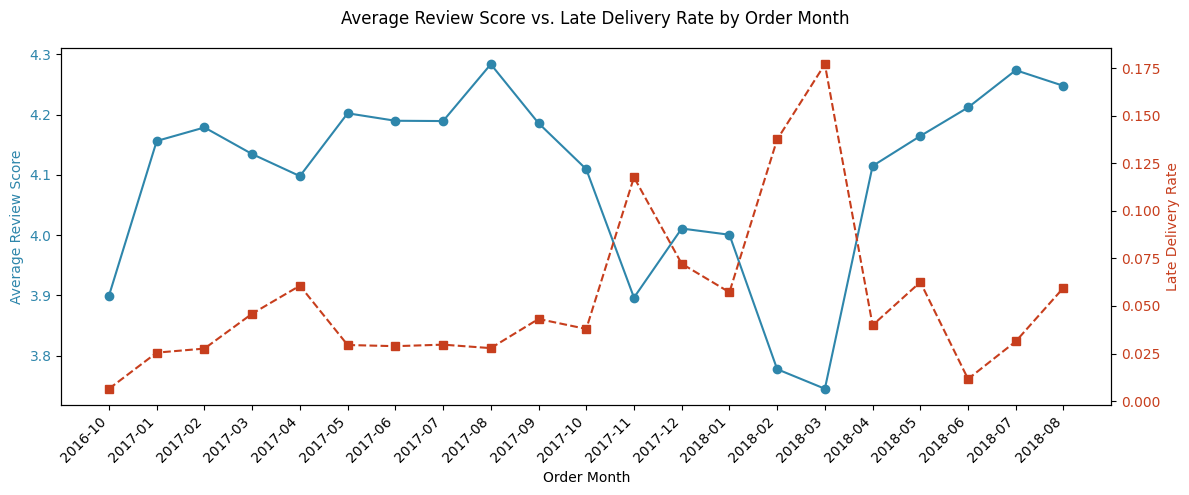

Correlation (monthly late rate vs. monthly avg review score): -0.77


In [7]:
monthly = (
    delivered
    .assign(month=delivered['order_purchase_timestamp'].dt.to_period('M').astype(str))
    .groupby('month')
    .agg(avg_review=('review_score', 'mean'), late_rate=('is_late', 'mean'), n_orders=('review_score', 'size'))
    .reset_index()
)
monthly = monthly[monthly['n_orders'] > 100]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly['month'], monthly['avg_review'], color='#2E86AB', marker='o', label='Avg. Review Score')
ax1.set_ylabel('Average Review Score', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.set_xlabel('Order Month')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['late_rate'], color='#C73E1D', marker='s', linestyle='--', label='Late Delivery Rate')
ax2.set_ylabel('Late Delivery Rate', color='#C73E1D')
ax2.tick_params(axis='y', labelcolor='#C73E1D')

fig.suptitle('Average Review Score vs. Late Delivery Rate by Order Month')
fig.tight_layout()
plt.show()

print(f"Correlation (monthly late rate vs. monthly avg review score): {monthly['avg_review'].corr(monthly['late_rate']):.2f}")


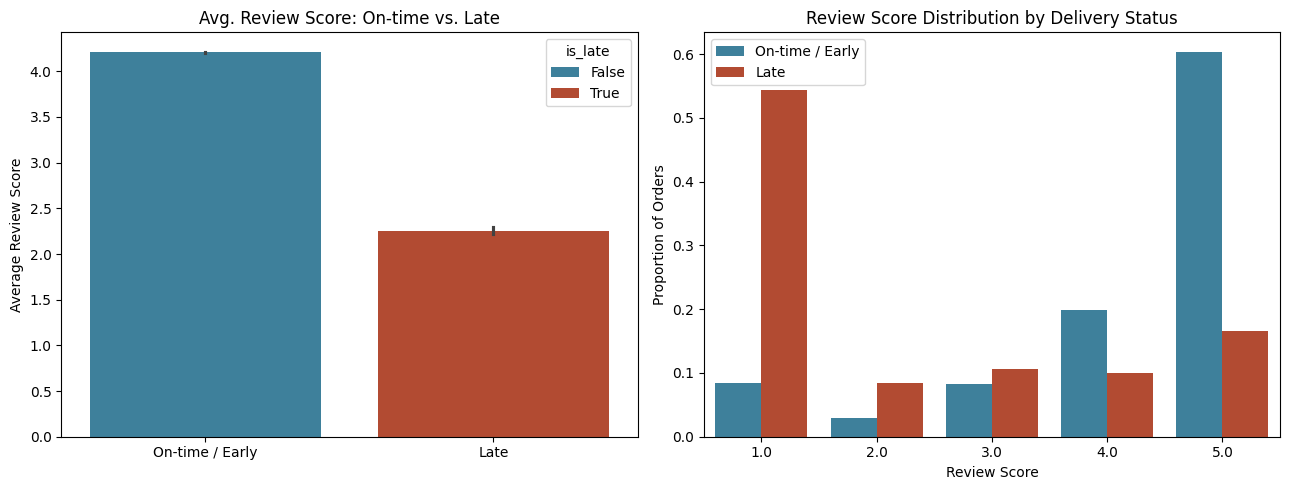

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=delivered, x='is_late', y='review_score', ax=axes[0], hue='is_late', palette=['#2E86AB', '#C73E1D'])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['On-time / Early', 'Late'])
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Review Score')
axes[0].set_title('Avg. Review Score: On-time vs. Late')

score_dist = (
    delivered
    .groupby('is_late')['review_score']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)
score_dist['is_late'] = score_dist['is_late'].map({False: 'On-time / Early', True: 'Late'})

sns.barplot(data=score_dist, x='review_score', y='proportion', hue='is_late', ax=axes[1], palette=['#2E86AB', '#C73E1D'])
axes[1].set_title('Review Score Distribution by Delivery Status')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Proportion of Orders')
axes[1].legend(title='')

plt.tight_layout()
plt.show()


These analysis indicates that delivery performance and review scores are consistently linked. Late deliveries make up a small share of completed orders, yet they carry a disproportionate share of dissatisfaction. On-time orders average higher review scores than late ones, and a large share of late orders result in the lowest rating (1-star). This pattern is consistent across the dataset's full timespan (month-over-month), not just in isolated batches meaning it's a structural relationship, not noise. 


## **1.2 Problem Statement**

Based on this evidence, the main problems this project addresses are:

1. **What factors are associated with late delivery, and what characterizes orders that are at higher risk of experiencing delays?**

2. **How can a machine learning model be developed to predict the likelihood of late delivery, so Olist can take proactive action to improve delivery performance and customer satisfaction before the delay (and the dissatisfaction it reliably causes) actually happens**

## **1.3 Key Objectives**

1. **Identify and characterize the factors behind late delivery**: analyze order, seller, customer, product, and logistics-related factors (e.g. which sellers, regions, shipping distances, or product categories show elevated late-delivery rates) so the problem can be localized and explained, not treated as random noise.

2. **Quantify the satisfaction cost of lateness**: translate "late" into a measurable drop in review score (and, by extension, into churn risk), so the business impact is stated in evidence rather than left anecdotal.

3. **Build a predictive risk model usable within a real intervention window**: develop a classification model that flags an order's late-delivery risk at, or shortly after, order approval (not just after the fact), so the prediction arrives early enough for operations to realistically act on it.

4. **Establish an evaluation framework aligned with business cost, not just statistical accuracy**: given the class imbalance in late vs. on-time orders, a naive "always predict on-time" model can score deceptively high on accuracy while catching zero real risk. (Objectives around metric selection and success criteria exist specifically to avoid that trap)

5. **Translate findings into concrete, actionable levers for Operations**: point toward actions Olist can actually take (seller SLAs, carrier choice, adding buffer to estimated delivery dates, proactive customer communication on at-risk orders), since delivery delay is largely a supply-side problem the platform can influence.

**Key stakeholder: Operations & Logistics Team**. These findings and this model are built for them to help them identify the drivers
behind delays, detect high-risk orders earlier, and prioritize proactive action to protect delivery performance and customer satisfaction.


## **1.4 Analytical Approach**

The analytical approach for this project consists of several systematic stages:

| **Stage** | **Implementation** |
|---|---|
| `Data Understanding` | Understand the structure and characteristics of the dataset, while identifying potential data issues such as inconsistencies, missing values, and anomalies. |
| `Exploratory Data Analysis (EDA)` | Conduct descriptive analysis and data visualization to identify patterns, relationships between variables, and factors associated with late delivery. |
| `Data Preprocessing` | Prepare and clean the data by handling missing values, outliers, categorical variables, and other data quality issues before modeling. |
| `Feature Engineering` | Create relevant features and transform existing variables to better represent the factors that may contribute to late delivery and improve model performance. |
| `Modeling` | Experiment with several machine learning algorithms to develop a model that can predict the likelihood of an order experiencing late delivery. |
| `Model Evaluation` | Evaluate model performance using metrics that are appropriate for the prediction objective and aligned with the business problem. |
| `Business Recommendation` | Translate the EDA findings and model results into actionable insights that can help Olist identify high-risk orders and improve delivery performance. |